**Deep Learning Assignment 5**

Assignement 5: Learn Decision trees for regression and classification problem

 a. Split the data set into training and test sets.

 b. Build the decision tree

 c. Check model performances on training and test data sets.

  d. Apply cost complexity pruning to overcome overfitting problem
  
   e. Apply Random Forest algorithm to overcome overfitting problem.
   
   f. Apply Ada-boost ensemble method on Decision stumps.




Decision Tree
Train R2: 0.6376786573648903
Test R2 : 0.5997321244428706
Test RMSE: 0.7242338143386247

Pruned Decision Tree
Train R2: 0.6310214009633045
Test R2 : 0.5974482515256707
Test RMSE: 0.72629706415993

Random Forest
Train R2: 0.8723082001725446
Test R2 : 0.774774131273305
Test RMSE: 0.5432660494744426

AdaBoost
Train R2: 0.4649574563204505
Test R2 : 0.4536023185680079
Test RMSE: 0.8461704482186159


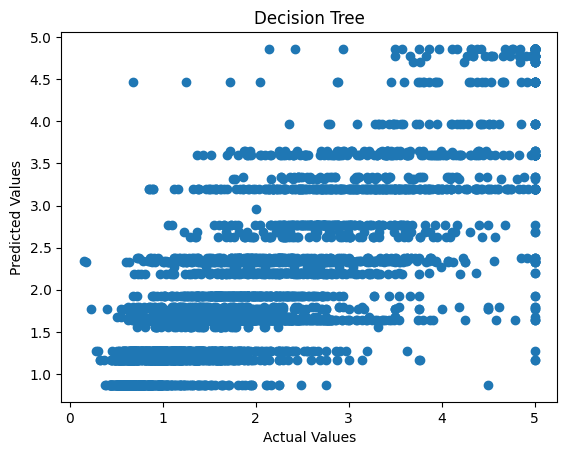

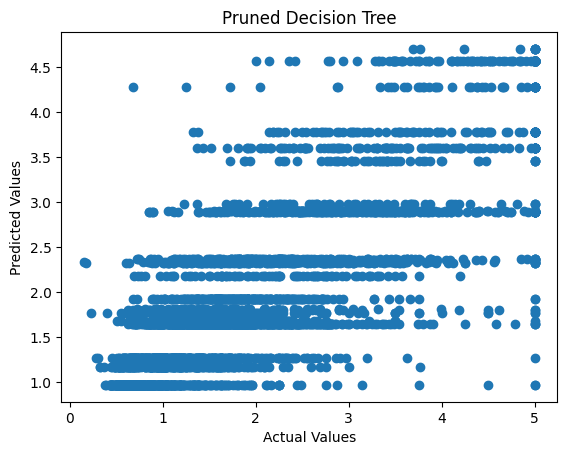

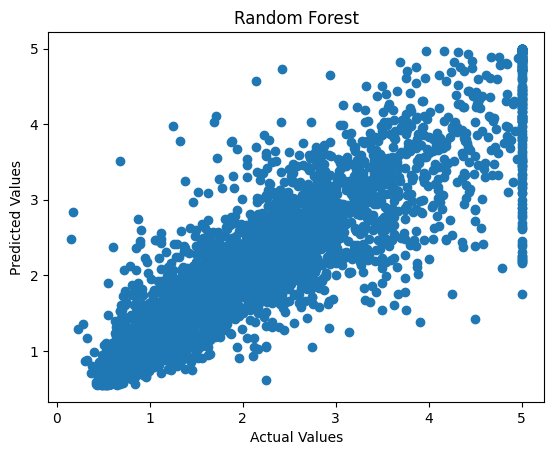

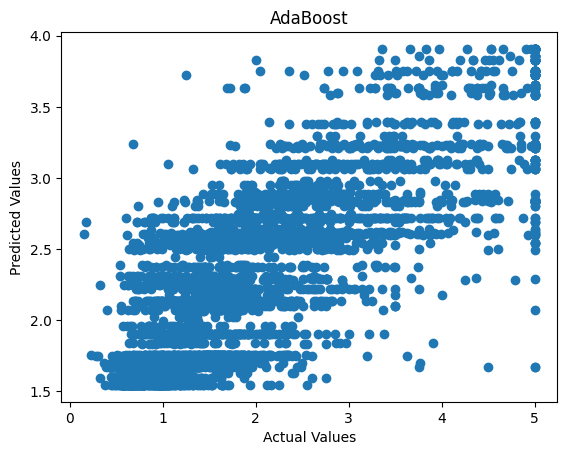

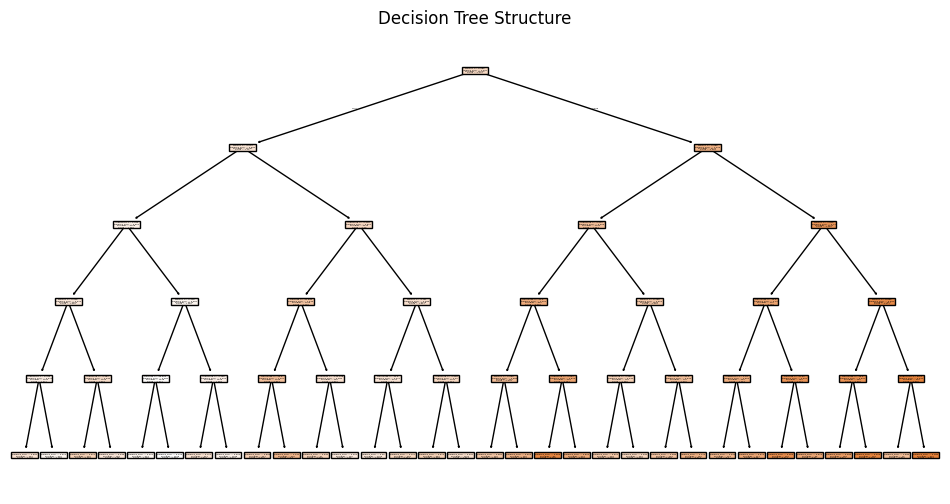

In [ ]:
# ==========================================
# Assignment 5: Decision Trees & Ensembles (Improved)
# Dataset: California Housing
# ==========================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
from sklearn.metrics import mean_squared_error, r2_score

# ------------------------------------------
# 1. Load Dataset
# ------------------------------------------
data = fetch_california_housing()
X = data.data
y = data.target

# ------------------------------------------
# 2. Train-Test Split
# ------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ------------------------------------------
# 3. Evaluation Function
# ------------------------------------------
def evaluate(name, y_train, y_train_pred, y_test, y_test_pred):
    print(f"\n{name}")
    print("Train R2:", r2_score(y_train, y_train_pred))
    print("Test R2 :", r2_score(y_test, y_test_pred))
    print("Test RMSE:", np.sqrt(mean_squared_error(y_test, y_test_pred)))

# ------------------------------------------
# 4. Decision Tree (Controlled Depth)
# ------------------------------------------
dt = DecisionTreeRegressor(max_depth=5, random_state=42)
dt.fit(X_train, y_train)

y_train_pred_dt = dt.predict(X_train)
y_test_pred_dt = dt.predict(X_test)

evaluate("Decision Tree", y_train, y_train_pred_dt, y_test, y_test_pred_dt)

# ------------------------------------------
# 5. Cost Complexity Pruning
# ------------------------------------------
path = dt.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas

best_alpha = ccp_alphas[len(ccp_alphas)//3]

dt_pruned = DecisionTreeRegressor(ccp_alpha=best_alpha, random_state=42)
dt_pruned.fit(X_train, y_train)

y_train_pred_pruned = dt_pruned.predict(X_train)
y_test_pred_pruned = dt_pruned.predict(X_test)

evaluate("Pruned Decision Tree", y_train, y_train_pred_pruned, y_test, y_test_pred_pruned)

# ------------------------------------------
# 6. Random Forest (Better tuning)
# ------------------------------------------
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

rf.fit(X_train, y_train)

y_train_pred_rf = rf.predict(X_train)
y_test_pred_rf = rf.predict(X_test)

evaluate("Random Forest", y_train, y_train_pred_rf, y_test, y_test_pred_rf)

# ------------------------------------------
# 7. AdaBoost (Improved)
# ------------------------------------------
ada = AdaBoostRegressor(
    DecisionTreeRegressor(max_depth=2),
    n_estimators=100,
    learning_rate=0.5,
    random_state=42
)

ada.fit(X_train, y_train)

y_train_pred_ada = ada.predict(X_train)
y_test_pred_ada = ada.predict(X_test)

evaluate("AdaBoost", y_train, y_train_pred_ada, y_test, y_test_pred_ada)

# ------------------------------------------
# 8. Visualization: Actual vs Predicted
# ------------------------------------------
def plot_results(y_test, y_pred, title):
    plt.figure()
    plt.scatter(y_test, y_pred)
    plt.xlabel("Actual Values")
    plt.ylabel("Predicted Values")
    plt.title(title)
    plt.show()

plot_results(y_test, y_test_pred_dt, "Decision Tree")
plot_results(y_test, y_test_pred_pruned, "Pruned Decision Tree")
plot_results(y_test, y_test_pred_rf, "Random Forest")
plot_results(y_test, y_test_pred_ada, "AdaBoost")

# ------------------------------------------
# 9. Tree Visualization (Small depth)
# ------------------------------------------
plt.figure(figsize=(12,6))
plot_tree(dt, filled=True, feature_names=data.feature_names)
plt.title("Decision Tree Structure")
plt.show()